В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, f1_score, roc_auc_score
import matplotlib.pyplot as plt


In [2]:
train_csv =  pd.read_csv('data/train.csv')

In [3]:
train_csv.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [ ]:
# Видаляємо непотрібні колонки з основного датафрейму
train_csv = train_csv.drop(columns=['CustomerId', 'Surname', 'RowNumber'], errors='ignore')

# Перевіряємо, чи вони зникли
print(train_csv.columns)

In [4]:
train_df, val_df = train_test_split(train_csv, test_size=0.2, random_state=42, stratify=train_csv['Exited'])

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [17]:
train_csv.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
input_cols = list(train_df.columns)[:-1]
target_col = 'Exited'

In [6]:
input_cols

['id',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [7]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [8]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [9]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_4379/2397943287.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


In [10]:
categorical_cols


['Surname', 'Geography', 'Gender']

In [11]:
numeric_cols

['id',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [12]:
imputer = SimpleImputer(strategy='median')

In [13]:
imputer.fit(train_inputs[numeric_cols])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [14]:
list(imputer.statistics_)

[np.float64(7471.5),
 np.float64(15689953.0),
 np.float64(661.0),
 np.float64(37.0),
 np.float64(5.0),
 np.float64(0.0),
 np.float64(2.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(123613.91)]

In [15]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])

In [13]:
train_inputs[numeric_cols].describe().round(2)

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,7479.63,15690923.99,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,4334.09,146930.97,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,0.00,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,3725.75,15635116.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,7471.50,15689953.00,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,11231.25,15756921.50,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,14999.00,15815690.00,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [16]:
train_inputs[categorical_cols].nunique()

Surname      732
Geography      3
Gender         2
dtype: int64

In [ ]:
duplicate_count = train_csv.duplicated().sum()
duplicate_count

np.int64(0)

In [19]:
scaler = MinMaxScaler()

In [20]:
scaler.fit(train_inputs[numeric_cols])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [21]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [22]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,0.54,0.35,0.50,0.21,0.20,0.79,0.49,0.59
std,0.17,0.15,0.28,0.29,0.18,0.41,0.50,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.42
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.62
75%,0.66,0.43,0.70,0.52,0.33,1.00,1.00,0.78
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [23]:
train_csv.Gender.describe()

count     15000
unique        2
top        Male
freq       8529
Name: Gender, dtype: object

In [24]:
sex_codes = {'female': 0, 'male': 1}

In [25]:
gender_codes = {'Female': 0, 'Male': 1}
train_inputs['gender_codes'] = train_inputs.Gender.map(gender_codes)

In [26]:
val_inputs['gender_codes'] = val_inputs.Gender.map(gender_codes)

In [27]:
val_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,1
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0
...,...,...,...,...,...,...,...,...,...,...,...
10550,0.589499,France,Male,0.357143,0.4,0.000000,0.333333,1.0,0.0,0.667682,1
8866,0.768496,France,Male,0.642857,0.6,0.000000,0.000000,1.0,0.0,0.885353,1
3244,0.589499,Spain,Male,0.250000,0.5,0.000000,0.333333,1.0,0.0,0.883589,1
12441,0.699284,Spain,Male,0.267857,0.5,0.658646,0.000000,1.0,0.0,0.528593,1


In [28]:
train_csv.Geography.describe()

count      15000
unique         3
top       France
freq        9032
Name: Geography, dtype: object

In [29]:
train_csv.Geography.value_counts()

Geography
France     9032
Spain      3303
Germany    2665
Name: count, dtype: int64

In [30]:
from sklearn import preprocessing

In [31]:
encoder = preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(train_inputs[['Geography']])
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object)]

In [32]:
one_hot = encoder.transform(train_inputs[['Geography']])

In [33]:
encoded_cols = list(encoder.get_feature_names_out(['Geography']))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain']


In [34]:
train_inputs[encoder.categories_[0]] = one_hot

In [35]:
print(train_inputs[encoder.categories_[0]].head())

       France  Germany  Spain
7180      1.0      0.0    0.0
10393     1.0      0.0    0.0
80        0.0      1.0    0.0
3365      0.0      0.0    1.0
12236     1.0      0.0    0.0


In [36]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes,France,Germany,Spain
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1,1.0,0.0,0.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0,1.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1,0.0,1.0,0.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,1,0.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,France,Female,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,0,1.0,0.0,0.0
8463,0.577566,France,Female,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,0,1.0,0.0,0.0
8143,0.453461,France,Male,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1,1.0,0.0,0.0
11512,0.379475,Spain,Male,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,1,0.0,0.0,1.0


In [37]:
val_one_hot = encoder.transform(val_inputs[['Geography']])
val_inputs[encoder.categories_[0]] = val_one_hot

In [38]:
display(train_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes,France,Germany,Spain
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1,1.0,0.0,0.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0,1.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1,0.0,1.0,0.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,1,0.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1,1.0,0.0,0.0


In [39]:
display(val_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes,France,Germany,Spain
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,1,0.0,1.0,0.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1,1.0,0.0,0.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,0,1.0,0.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,0,1.0,0.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0,0.0,0.0,1.0



1. Очищення та валідація даних

* Перевірка якості: Перевірено датасет на наявність пропусків  та дублікатів, яких не виявилося.
* Страховка (Imputation): Попри відсутність пропусків, застосовано `SimpleImputer(strategy='median')`. Це гарна практика: якщо в майбутньому модель отримає нові дані з "NaN", вона не зламається, а автоматично заповнить їх медіаною.

2. Робота з категоріальними ознаками

* Бінарне кодування:Стать (`Gender`) була перетворена на `gender_codes`. Оскільки категорій всього дві, одного стовпця з 0 та 1 достатньо. 1 - male, оскільки це домінуючий гендер
* One-Hot Encoding: Для `Geography` (Франція, Німеччина, Іспанія) використано `OneHotEncoder`. 
* Видалення нерелевантних даних: Прізвища (`Surname`) були видалені. Це логічно: прізвище — це унікальний шум, який не несе статистичної ваги для прогнозу відтоку. 


* Видалення технічних полів: Видалино `CustomerId`. Це критично важливо, щоб модель не "зазубрила" випадкові ID, а вчилася на реальних характеристиках клієнтів.
* Очищення входу:Видалкно оригінальні текстові колонки (`Geography`, `Gender`), залишивши лише їхні числові еквіваленти. 


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [40]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

In [41]:
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [42]:
ls

HW_2_2_Логістична_регресія_з_scikit_learn.ipynb
data/
train_inputs.parquet
train_targets.parquet
val_inputs.parquet
val_targets.parquet
Класафікація. Логістична регресія/
Лінійна регресія/


In [3]:
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')
val_targets = pd.read_parquet('val_targets.parquet')

In [44]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 14)
train_targets: (12000, 1)
val_inputs: (3000, 14)
val_targets: (3000, 1)


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [4]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes,France,Germany,Spain
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1,1.0,0.0,0.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0,1.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1,0.0,1.0,0.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,1,0.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,France,Female,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,0,1.0,0.0,0.0
8463,0.577566,France,Female,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,0,1.0,0.0,0.0
8143,0.453461,France,Male,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1,1.0,0.0,0.0
11512,0.379475,Spain,Male,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,1,0.0,0.0,1.0


In [51]:
encoded_cols

['Geography_France', 'Geography_Germany', 'Geography_Spain']

In [52]:
numeric_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [53]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes,France,Germany,Spain
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1,1.0,0.0,0.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0,1.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1,0.0,1.0,0.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,1,0.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,France,Female,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,0,1.0,0.0,0.0
8463,0.577566,France,Female,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,0,1.0,0.0,0.0
8143,0.453461,France,Male,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1,1.0,0.0,0.0
11512,0.379475,Spain,Male,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,1,0.0,0.0,1.0


In [50]:
X_train = train_inputs[numeric_cols + encoded_cols]

KeyError: "['Geography_France', 'Geography_Germany', 'Geography_Spain'] not in index"

In [49]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes,France,Germany,Spain
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1,1.0,0.0,0.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0,1.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1,0.0,1.0,0.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,1,0.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,France,Female,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,0,1.0,0.0,0.0
8463,0.577566,France,Female,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,0,1.0,0.0,0.0
8143,0.453461,France,Male,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1,1.0,0.0,0.0
11512,0.379475,Spain,Male,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,1,0.0,0.0,1.0


In [45]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,gender_codes,France,Germany,Spain
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1,1.0,0.0,0.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0,1.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1,0.0,1.0,0.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,1,0.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,France,Female,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,0,1.0,0.0,0.0
8463,0.577566,France,Female,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,0,1.0,0.0,0.0
8143,0.453461,France,Male,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1,1.0,0.0,0.0
11512,0.379475,Spain,Male,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,1,0.0,0.0,1.0


In [61]:
X_train = train_inputs[numeric_cols + encoded_cols]

KeyError: "['Geography_France', 'Geography_Germany', 'Geography_Spain'] not in index"

In [62]:
model = LogisticRegression(solver='liblinear', random_state=42)

In [63]:
model.fit(X_train, train_targets)

ValueError: could not convert string to float: 'France'

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [57]:
from sklearn.metrics import confusion_matrix

In [55]:
train_preds = model.predict(X_train)
train_preds

array([0., 0., 0., ..., 0., 0., 0.], shape=(12000,))

In [ ]:
val_preds = model.predict(X_val)


In [59]:
confusion_matrix(train_targets, train_preds)

array([[9177,  381],
       [1128, 1314]])

In [61]:
confusion_matrix(val_targets, val_preds)

array([[2271,  119],
       [ 266,  344]])

In [68]:
def compute_metrics_and_plot_roc(inputs, targets, name=''):
    # 1. Predict probabilities for the positive class
    y_pred_proba = model.predict_proba(inputs)[:, 1]
    
    # 2. Predict classes using the default 0.5 threshold for F1 Score
    y_pred = model.predict(inputs)
    
    # 3. Compute metrics
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(targets, y_pred)
    
    # Print metrics to console
    print(f'--- Metrics for {name} ---')
    print(f'AUROC: {roc_auc:.4f}')
    print(f'F1 Score (threshold 0.5): {f1:.4f}')

    # 4. Plot the ROC curve
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'Receiver Operating Characteristic (ROC) - {name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.show()

--- Metrics for Training ---
AUROC: 0.8824
F1 Score (threshold 0.5): 0.6352


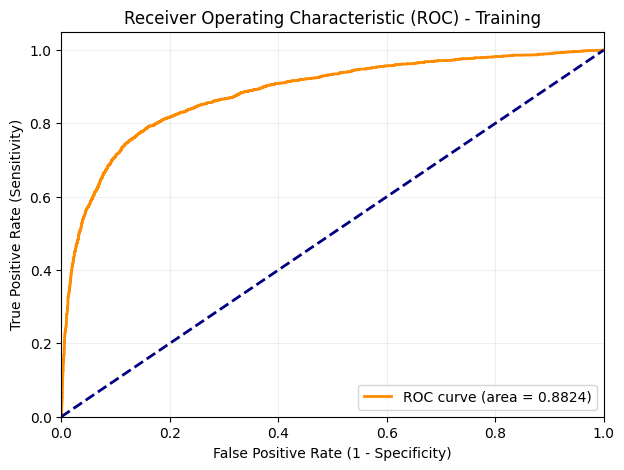

--- Metrics for Validation ---
AUROC: 0.8797
F1 Score (threshold 0.5): 0.6412


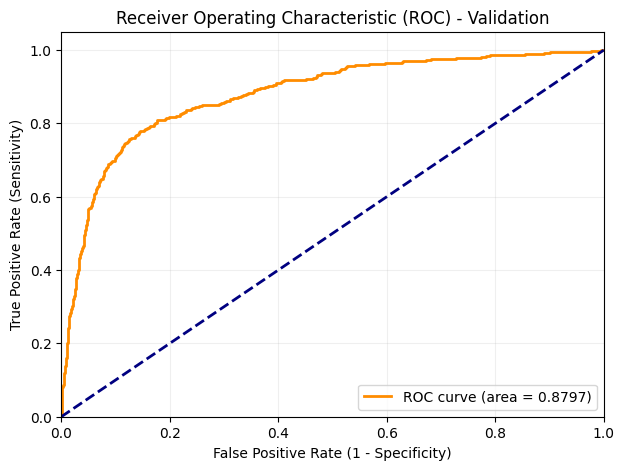

In [69]:
compute_metrics_and_plot_roc(X_train, train_targets, 'Training')
compute_metrics_and_plot_roc(X_val, val_targets, 'Validation')

1. Відсутність перенавчання (No Overfitting)

Показники на навчальних (`0.8824`) та валідаційних (`0.8797`) даних **майже однакові**. Різниця в AUROC становить лише **0.0027**.

2. Якість роздільної здатності (AUROC)

Показник **0.88** вважається **дуже хорошим (Good/Excellent)** для банківської сфери та задач прогнозування відтоку.

* Це означає, що у 88% випадків модель правильно поставить вищу ймовірність відтоку клієнту, який дійсно збирається піти, порівняно з випадковим лояльним клієнтом.

3. Аналіз F1-Score (0.64)

Хоча AUROC високий, **F1-Score (~0.64)** 

Модель - хороша.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [ ]:
majority_class = train_targets['Exited'].mode()[0]
print(f"Majority class (most frequent): {majority_class}")

dummy_train_preds = [majority_class] * len(train_targets)
dummy_val_preds = [majority_class] * len(val_targets)

model_train_acc = accuracy_score(train_targets, model.predict(X_train))
model_val_acc = accuracy_score(val_targets, model.predict(X_val))

dummy_train_acc = accuracy_score(train_targets, dummy_train_preds)
dummy_val_acc = accuracy_score(val_targets, dummy_val_preds)

Majority class (most frequent): 0.0


In [77]:
print(f"\n--- Accuracy Comparison ---")
print(f"Logistic Regression (Train): {model_train_acc:.4f}")
print(f"Logistic Regression (Val):   {model_val_acc:.4f}")
print(f"Majority Baseline (Train):   {dummy_train_acc:.4f}")
print(f"Majority Baseline (Val):     {dummy_val_acc:.4f}")


--- Accuracy Comparison ---
Logistic Regression (Train): 0.8742
Logistic Regression (Val):   0.8717
Majority Baseline (Train):   0.7965
Majority Baseline (Val):     0.7967


Модель має точність 87.17% на валідації, тоді як просте передбачення мажоритарного класу (якщо ми просто скажемо, що ніхто не піде) дає лише 79.67%.

Це означає, що логістична регресія додала ~7.5% чистої точності.

У масштабах банку це дозволяє виявити сотні клієнтів, які насправді планують піти, чого "мажоритарна" модель зробити б не змогла.

Отже, модель хороша

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [96]:
log_reg_data = {
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'encoder': enc,
    'input_cols': X_train.columns.tolist(),
    'numeric_cols': numeric_cols,     
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [97]:
joblib.dump(log_reg_data, 'log_reg.joblib')

['log_reg.joblib']

In [98]:
loaded_data = joblib.load('log_reg.joblib')
model_2 = loaded_data['model']

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [107]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, enc, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = enc.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [108]:
predict_raw_df(scaler, enc, numeric_cols, categorical_cols, train_csv[:5])

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Gender
- Surname


In [41]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

NameError: name 'encoder' is not defined

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.